# name: seba saud

# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [62]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"
df = pd.read_csv(url)
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [64]:
X = df[['Experience Years']]
y = df['Salary']

### Step 2.b print the type of each

In [65]:
print (type(X))
print (type(y))


<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [66]:
# TARGET = NUMRICAL 
# TASK = REGRESSION


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [67]:
print(f"X (Features) shape: {X.shape}")
print(f"y (Target) shape: {y.shape}")

X (Features) shape: (40, 1)
y (Target) shape: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [68]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

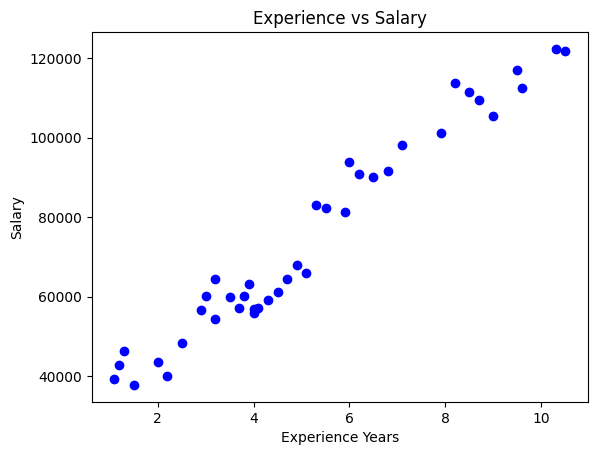

In [69]:
plt.scatter(X, y, color='blue')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

# increasing // positive  relationship

### Step 7. Initialize a regression model

In [70]:
model = LinearRegression()
print(model)

LinearRegression()


### Step 8. Split the dataset into train and test sets

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



### Step 9.a Train the model on the training set

In [72]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [73]:
print(f"Slope (Coefficient): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Slope (Coefficient): 9408.03127250658
Intercept: 26716.250176145535


### Step 9.c how much salary does a person get with 2 years of experience?

In [74]:
salary_2 = model.predict([[2]])
print(f"Predicted salary for 2 years: {salary_2[0]}")

Predicted salary for 2 years: 45532.3127211587


c:\Users\HP\OneDrive\Desktop\AAI\B5\Student\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [75]:
# 6 months = 0.5 year. The increase is slope * 0.5
increase = model.coef_[0] * 0.5
print(f"Increase for 6 months: {increase}")

Increase for 6 months: 4704.01563625329


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [76]:
# It's the intercept value
print(f"Salary with zero experience: {model.intercept_}")

Salary with zero experience: 26716.250176145535


### Step 10. Evaluate the model on the test set

In [77]:
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.9068577573647874


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [78]:
sample_X = X_test.head(3)
sample_y = y_test.head(3)
predictions = model.predict(sample_X)

comparison = pd.DataFrame({'Actual': sample_y, 'Predicted': predictions})
print(comparison)

    Actual     Predicted
19   61111  69052.390902
16   56957  64348.375266
15   55794  64348.375266


### Step 12. Plot the data and the regression line

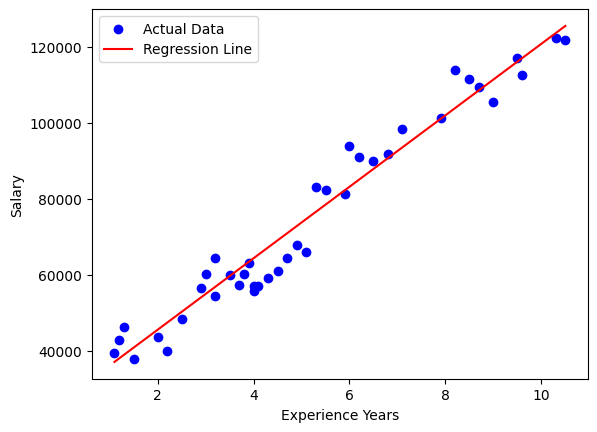

In [79]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.legend()
plt.show()